/var/folders/m1/qxpcclg55hg_8gcmt4vpkrq80000gn/T/ipykernel_76258/69805207.py:45: DeprecationWarning: Callback API version 1 is deprecated, update to latest version
  client = mqtt.Client()


Starting 10s data collection...
✅ Connected to MQTT broker
📡 Samples collected: 250
📦 Total collection time: 10.04 sec

──── IMU Sampling Summary ────
Samples received: 250
Average frequency: 25.01 Hz
Mean interval: 39.990 ms
Jitter: 5.829 ms

💾 Data saved to: data/imu_data_20251030_093202_250samples_10s.csv


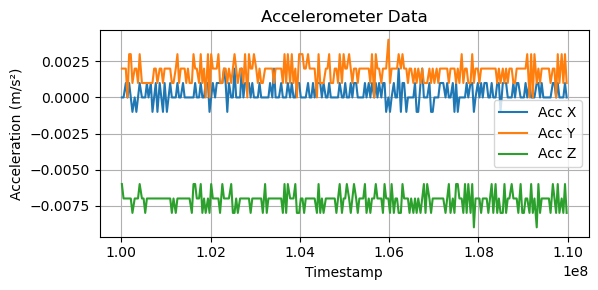

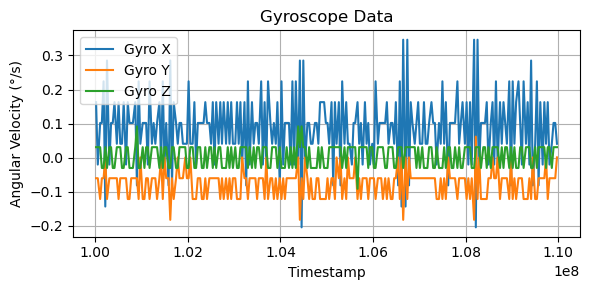

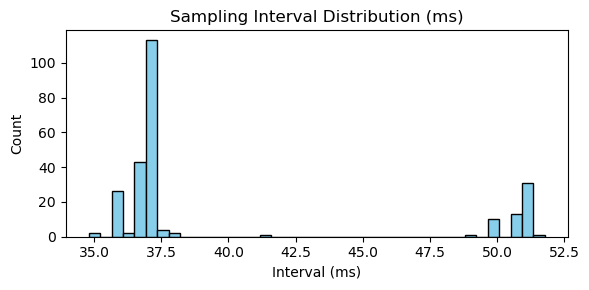

In [1]:
import paho.mqtt.client as mqtt
import pandas as pd
import re
import matplotlib.pyplot as plt
import numpy as np
import time
from datetime import datetime
import os

# ─── Config ────────────────────────────────────────────────
BROKER_ADDRESS = "127.0.0.1"
MQTT_TOPIC = "imu/data"
RECORD_SECONDS = 10          # duration to record, in seconds
OUTPUT_DIR = "data"          # folder to save CSV files

os.makedirs(OUTPUT_DIR, exist_ok=True)

imu_data = []
collecting = True

# ─── MQTT Callbacks ─────────────────────────────────────────
def on_connect(client, userdata, flags, rc):
    if rc == 0:
        print("✅ Connected to MQTT broker")
        client.subscribe(MQTT_TOPIC)
    else:
        print(f"❌ Connection failed with code {rc}")

def on_message(client, userdata, msg):
    global imu_data, collecting
    if not collecting:
        return

    payload = msg.payload.decode("utf-8").strip()
    # Extract 7 numerical values inside [[...]]
    match = re.findall(r"\[([0-9\.,\- ]+)\]", payload)
    if not match:
        return
    values = [float(v) for v in match[0].split(",")]
    if len(values) == 7:
        imu_data.append(values)
    print(f"📡 Samples collected: {len(imu_data)}", end="\r")

# ─── Collect Data for a Fixed Duration ──────────────────────
client = mqtt.Client()
client.on_connect = on_connect
client.on_message = on_message

print(f"Starting {RECORD_SECONDS}s data collection...")
client.connect(BROKER_ADDRESS, 1883, 60)
client.loop_start()

start_time = time.time()
while time.time() - start_time < RECORD_SECONDS:
    time.sleep(0.05)

collecting = False
client.loop_stop()
client.disconnect()
elapsed = time.time() - start_time

print(f"\n📦 Total collection time: {elapsed:.2f} sec")

# ─── Convert to DataFrame ───────────────────────────────────
if len(imu_data) == 0:
    print("⚠️ No data received.")
else:
    columns = ["timestamp", "acc_x", "acc_y", "acc_z", "gyro_x", "gyro_y", "gyro_z"]
    df = pd.DataFrame(imu_data, columns=columns)

    # Compute timing metrics
    df["dt"] = df["timestamp"].diff()
    df.loc[df["dt"] < 0, "dt"] += 2**32
    df["dt_sec"] = df["dt"] / 1_000_000.0

    avg_freq = 1 / df["dt_sec"].mean()
    jitter_ms = df["dt_sec"].std() * 1000

    print("\n──── IMU Sampling Summary ────")
    print(f"Samples received: {len(df)}")
    print(f"Average frequency: {avg_freq:.2f} Hz")
    print(f"Mean interval: {df['dt_sec'].mean()*1000:.3f} ms")
    print(f"Jitter: {jitter_ms:.3f} ms")

    # ─── Save to CSV ─────────────────────────────────────────
    date_str = datetime.now().strftime("%Y%m%d_%H%M%S")
    filename = f"imu_data_{date_str}_{len(df)}samples_{RECORD_SECONDS}s.csv"
    filepath = os.path.join(OUTPUT_DIR, filename)
    df.to_csv(filepath, index=False)
    print(f"\n💾 Data saved to: {filepath}")

    # ─── Visualization ───────────────────────────────────────
    plt.figure(figsize=(6, 3))
    plt.plot(df["timestamp"], df["acc_x"], label="Acc X")
    plt.plot(df["timestamp"], df["acc_y"], label="Acc Y")
    plt.plot(df["timestamp"], df["acc_z"], label="Acc Z")
    plt.legend()
    plt.title("Accelerometer Data")
    plt.xlabel("Timestamp")
    plt.ylabel("Acceleration (m/s²)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 3))
    plt.plot(df["timestamp"], df["gyro_x"], label="Gyro X")
    plt.plot(df["timestamp"], df["gyro_y"], label="Gyro Y")
    plt.plot(df["timestamp"], df["gyro_z"], label="Gyro Z")
    plt.legend()
    plt.title("Gyroscope Data")
    plt.xlabel("Timestamp")
    plt.ylabel("Angular Velocity (°/s)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 3))
    plt.hist(df["dt_sec"] * 1000, bins=40, color='skyblue', edgecolor='k')
    plt.title("Sampling Interval Distribution (ms)")
    plt.xlabel("Interval (ms)")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


/var/folders/m1/qxpcclg55hg_8gcmt4vpkrq80000gn/T/ipykernel_76258/69805207.py:45: DeprecationWarning: Callback API version 1 is deprecated, update to latest version
  client = mqtt.Client()


Starting 10s data collection...
✅ Connected to MQTT broker
📡 Samples collected: 251
📦 Total collection time: 10.07 sec

──── IMU Sampling Summary ────
Samples received: 251
Average frequency: 25.00 Hz
Mean interval: 40.006 ms
Jitter: 5.721 ms

💾 Data saved to: data/imu_data_20251030_093223_251samples_10s.csv


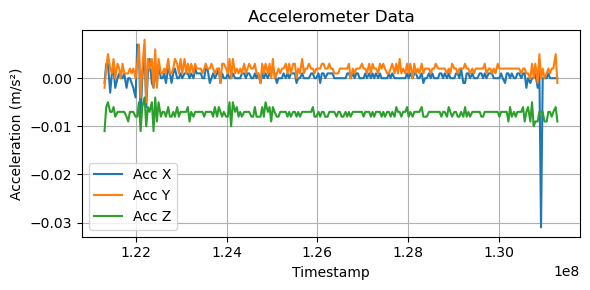

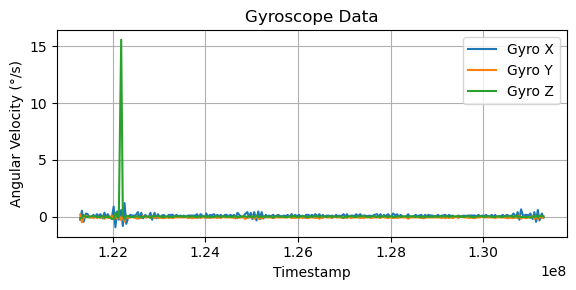

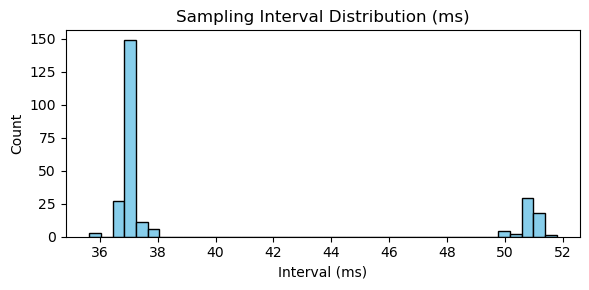

In [2]:
import paho.mqtt.client as mqtt
import pandas as pd
import re
import matplotlib.pyplot as plt
import numpy as np
import time
from datetime import datetime
import os

# ─── Config ────────────────────────────────────────────────
BROKER_ADDRESS = "127.0.0.1"
MQTT_TOPIC = "imu/data"
RECORD_SECONDS = 10          # duration to record, in seconds
OUTPUT_DIR = "data"          # folder to save CSV files

os.makedirs(OUTPUT_DIR, exist_ok=True)

imu_data = []
collecting = True

# ─── MQTT Callbacks ─────────────────────────────────────────
def on_connect(client, userdata, flags, rc):
    if rc == 0:
        print("✅ Connected to MQTT broker")
        client.subscribe(MQTT_TOPIC)
    else:
        print(f"❌ Connection failed with code {rc}")

def on_message(client, userdata, msg):
    global imu_data, collecting
    if not collecting:
        return

    payload = msg.payload.decode("utf-8").strip()
    # Extract 7 numerical values inside [[...]]
    match = re.findall(r"\[([0-9\.,\- ]+)\]", payload)
    if not match:
        return
    values = [float(v) for v in match[0].split(",")]
    if len(values) == 7:
        imu_data.append(values)
    print(f"📡 Samples collected: {len(imu_data)}", end="\r")

# ─── Collect Data for a Fixed Duration ──────────────────────
client = mqtt.Client()
client.on_connect = on_connect
client.on_message = on_message

print(f"Starting {RECORD_SECONDS}s data collection...")
client.connect(BROKER_ADDRESS, 1883, 60)
client.loop_start()

start_time = time.time()
while time.time() - start_time < RECORD_SECONDS:
    time.sleep(0.05)

collecting = False
client.loop_stop()
client.disconnect()
elapsed = time.time() - start_time

print(f"\n📦 Total collection time: {elapsed:.2f} sec")

# ─── Convert to DataFrame ───────────────────────────────────
if len(imu_data) == 0:
    print("⚠️ No data received.")
else:
    columns = ["timestamp", "acc_x", "acc_y", "acc_z", "gyro_x", "gyro_y", "gyro_z"]
    df = pd.DataFrame(imu_data, columns=columns)

    # Compute timing metrics
    df["dt"] = df["timestamp"].diff()
    df.loc[df["dt"] < 0, "dt"] += 2**32
    df["dt_sec"] = df["dt"] / 1_000_000.0

    avg_freq = 1 / df["dt_sec"].mean()
    jitter_ms = df["dt_sec"].std() * 1000

    print("\n──── IMU Sampling Summary ────")
    print(f"Samples received: {len(df)}")
    print(f"Average frequency: {avg_freq:.2f} Hz")
    print(f"Mean interval: {df['dt_sec'].mean()*1000:.3f} ms")
    print(f"Jitter: {jitter_ms:.3f} ms")

    # ─── Save to CSV ─────────────────────────────────────────
    date_str = datetime.now().strftime("%Y%m%d_%H%M%S")
    filename = f"imu_data_{date_str}_{len(df)}samples_{RECORD_SECONDS}s.csv"
    filepath = os.path.join(OUTPUT_DIR, filename)
    df.to_csv(filepath, index=False)
    print(f"\n💾 Data saved to: {filepath}")

    # ─── Visualization ───────────────────────────────────────
    plt.figure(figsize=(6, 3))
    plt.plot(df["timestamp"], df["acc_x"], label="Acc X")
    plt.plot(df["timestamp"], df["acc_y"], label="Acc Y")
    plt.plot(df["timestamp"], df["acc_z"], label="Acc Z")
    plt.legend()
    plt.title("Accelerometer Data")
    plt.xlabel("Timestamp")
    plt.ylabel("Acceleration (m/s²)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 3))
    plt.plot(df["timestamp"], df["gyro_x"], label="Gyro X")
    plt.plot(df["timestamp"], df["gyro_y"], label="Gyro Y")
    plt.plot(df["timestamp"], df["gyro_z"], label="Gyro Z")
    plt.legend()
    plt.title("Gyroscope Data")
    plt.xlabel("Timestamp")
    plt.ylabel("Angular Velocity (°/s)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 3))
    plt.hist(df["dt_sec"] * 1000, bins=40, color='skyblue', edgecolor='k')
    plt.title("Sampling Interval Distribution (ms)")
    plt.xlabel("Interval (ms)")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


/var/folders/m1/qxpcclg55hg_8gcmt4vpkrq80000gn/T/ipykernel_76258/2257424043.py:46: DeprecationWarning: Callback API version 1 is deprecated, update to latest version
  client = mqtt.Client()


Starting 20s data collection...
✅ Connected to MQTT broker
📡 Samples collected: 501
📦 Total collection time: 20.06 sec

──── IMU Sampling Summary ────
Samples received: 501
Average frequency: 25.00 Hz
Mean interval: 39.999 ms
Jitter: 5.776 ms

💾 Data saved to: data/imu_data_20251030_093253_501samples_20s.csv


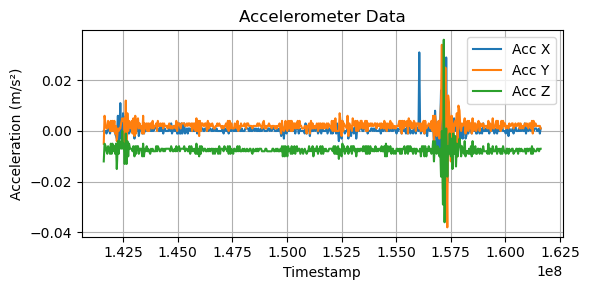

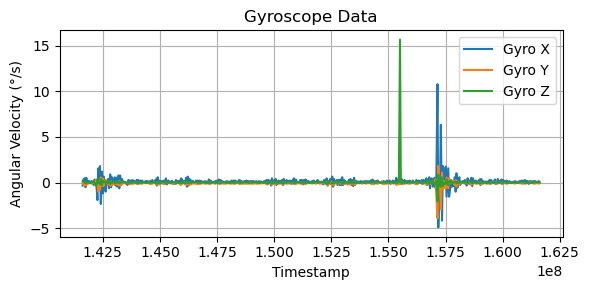

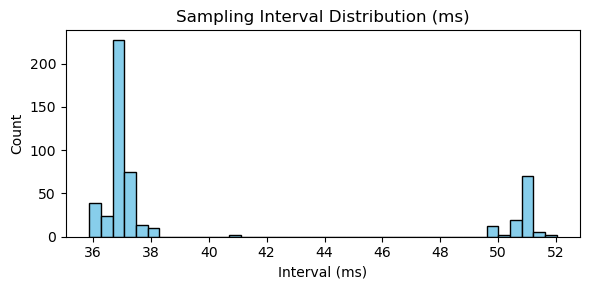

In [3]:
import paho.mqtt.client as mqtt
import pandas as pd
import re
import matplotlib.pyplot as plt
import numpy as np

import time
from datetime import datetime
import os

# ─── Config ────────────────────────────────────────────────
BROKER_ADDRESS = "127.0.0.1"
MQTT_TOPIC = "imu/data"
RECORD_SECONDS = 20          # duration to record, in seconds
OUTPUT_DIR = "data"          # folder to save CSV files

os.makedirs(OUTPUT_DIR, exist_ok=True)

imu_data = []
collecting = True

# ─── MQTT Callbacks ─────────────────────────────────────────
def on_connect(client, userdata, flags, rc):
    if rc == 0:
        print("✅ Connected to MQTT broker")
        client.subscribe(MQTT_TOPIC)
    else:
        print(f"❌ Connection failed with code {rc}")

def on_message(client, userdata, msg):
    global imu_data, collecting
    if not collecting:
        return

    payload = msg.payload.decode("utf-8").strip()
    # Extract 7 numerical values inside [[...]]
    match = re.findall(r"\[([0-9\.,\- ]+)\]", payload)
    if not match:
        return
    values = [float(v) for v in match[0].split(",")]
    if len(values) == 7:
        imu_data.append(values)
    print(f"📡 Samples collected: {len(imu_data)}", end="\r")

# ─── Collect Data for a Fixed Duration ──────────────────────
client = mqtt.Client()
client.on_connect = on_connect
client.on_message = on_message

print(f"Starting {RECORD_SECONDS}s data collection...")
client.connect(BROKER_ADDRESS, 1883, 60)
client.loop_start()

start_time = time.time()
while time.time() - start_time < RECORD_SECONDS:
    time.sleep(0.05)

collecting = False
client.loop_stop()
client.disconnect()
elapsed = time.time() - start_time

print(f"\n📦 Total collection time: {elapsed:.2f} sec")

# ─── Convert to DataFrame ───────────────────────────────────
if len(imu_data) == 0:
    print("⚠️ No data received.")
else:
    columns = ["timestamp", "acc_x", "acc_y", "acc_z", "gyro_x", "gyro_y", "gyro_z"]
    df = pd.DataFrame(imu_data, columns=columns)

    # Compute timing metrics
    df["dt"] = df["timestamp"].diff()
    df.loc[df["dt"] < 0, "dt"] += 2**32
    df["dt_sec"] = df["dt"] / 1_000_000.0

    avg_freq = 1 / df["dt_sec"].mean()
    jitter_ms = df["dt_sec"].std() * 1000

    print("\n──── IMU Sampling Summary ────")
    print(f"Samples received: {len(df)}")
    print(f"Average frequency: {avg_freq:.2f} Hz")
    print(f"Mean interval: {df['dt_sec'].mean()*1000:.3f} ms")
    print(f"Jitter: {jitter_ms:.3f} ms")

    # ─── Save to CSV ─────────────────────────────────────────
    date_str = datetime.now().strftime("%Y%m%d_%H%M%S")
    filename = f"imu_data_{date_str}_{len(df)}samples_{RECORD_SECONDS}s.csv"
    filepath = os.path.join(OUTPUT_DIR, filename)
    df.to_csv(filepath, index=False)
    print(f"\n💾 Data saved to: {filepath}")

    # ─── Visualization ───────────────────────────────────────
    plt.figure(figsize=(6, 3))
    plt.plot(df["timestamp"], df["acc_x"], label="Acc X")
    plt.plot(df["timestamp"], df["acc_y"], label="Acc Y")
    plt.plot(df["timestamp"], df["acc_z"], label="Acc Z")
    plt.legend()
    plt.title("Accelerometer Data")
    plt.xlabel("Timestamp")
    plt.ylabel("Acceleration (m/s²)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 3))
    plt.plot(df["timestamp"], df["gyro_x"], label="Gyro X")
    plt.plot(df["timestamp"], df["gyro_y"], label="Gyro Y")
    plt.plot(df["timestamp"], df["gyro_z"], label="Gyro Z")
    plt.legend()
    plt.title("Gyroscope Data")
    plt.xlabel("Timestamp")
    plt.ylabel("Angular Velocity (°/s)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 3))
    plt.hist(df["dt_sec"] * 1000, bins=40, color='skyblue', edgecolor='k')
    plt.title("Sampling Interval Distribution (ms)")
    plt.xlabel("Interval (ms)")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()
